# Experiment A: Common Emotionalization Direction Residualization

## Motivation

The global CAA vectors for different emotions are often extremely similar. This suggests that the largest direction in the space is not joy-specific or sadness-specific, but a shared **"neutral → emotional"** direction: the model represents the transition from neutral language to emotional language as a single dominant axis.

If we want to understand what makes *joy* different from *sadness*, we need to remove this shared component first.

## Method

Let $c_e$ be the global pooled CAA vector for emotion $e$ at a given layer.

1. Compute the common emotionalization direction: $g = \frac{\bar{c}}{\|\bar{c}\|}$ where $\bar{c} = \frac{1}{|E|}\sum_e c_e$
2. Residualize each emotion direction: $c^\text{resid}_e = c_e - (c_e \cdot g)\, g$
3. Unit-normalize for cosine geometry: $\hat{c}^\text{resid}_e = c^\text{resid}_e / \|c^\text{resid}_e\|$

## What would count as evidence for emotion-specific structure?

- **Increased pairwise cosine diversity**: Before residualization, all cosines may be near 1. After, we expect more variation — some pairs negative, others positive.
- **Increased participation ratio**: If the original directions collapse to PR≈1 (all pointing the same way), residualization should reveal higher effective dimensionality.
- **Plutchik opposite pairs become less similar**: joy↔sadness, trust↔disgust, etc. should become more distinguishable.
- **Cleaner 2D/3D structure**: The PCA projection should show more spread and separation.

## What would count as evidence against it?

- After residualization, all residual vectors are near zero (directions are almost identical to $g$).
- No meaningful geometry emerges (PR still low, all cosines near zero).
- Emotion-specific directions may be distributed across many small components rather than a low-dimensional subspace.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

REPO_ROOT = Path('../..').resolve()
ACT_DIR   = REPO_ROOT / 'activation' / 'emotion_rewrites'
CAA_PATH  = ACT_DIR / 'caa_emotion_directions.npz'
INFO_PATH = ACT_DIR / 'caa_emotion_directions_info.json'
OUT_DIR   = REPO_ROOT / 'analysis' / 'caa' / 'common_direction_residualization'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_LAYER = 13

sns.set_context('notebook')
sns.set_style('whitegrid')

In [ ]:
with open(INFO_PATH) as f:
    INFO = json.load(f)

EMOTION_ORDER   = INFO['emotion_order']   # 8 emotions
INTENSITY_ORDER = INFO['intensity_order'] # ['low','medium','high']
LAYER_INDICES   = INFO['layer_indices']   # [8, 10, 13, 16, 19, 22]
LI_MAP          = {l: i for i, l in enumerate(LAYER_INDICES)}
N_EMO = len(EMOTION_ORDER)
N_LAY = len(LAYER_INDICES)

data       = np.load(CAA_PATH)
# caa_pooled[e, l, :] = unit_norm(mean_{n,i}(h_emotion - h_neutral)), shape (8, 6, 4096)
# delta_mean[e, i, l, :] = raw mean difference, shape (8, 3, 6, 4096)
CAA_POOLED = data['caa_pooled']  # (8, 6, 4096) — already unit-normed
DELTA_MEAN = data['delta_mean']  # (8, 3, 6, 4096) — raw magnitudes

print('CAA_POOLED shape:', CAA_POOLED.shape)
print('DELTA_MEAN shape:', DELTA_MEAN.shape)
print('Emotions:', EMOTION_ORDER)
print('Layers:  ', LAYER_INDICES)


CAA_POOLED shape: (8, 6, 4096)
DELTA_MEAN shape: (8, 3, 6, 4096)
Emotions: ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
Layers:   [8, 10, 13, 16, 19, 22]


In [3]:
# ── Helpers ───────────────────────────────────────────────────────────────────

def unit(v: np.ndarray) -> np.ndarray:
    """Unit-normalize vector(s) along last axis."""
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / (n + 1e-12)

def participation_ratio(s: np.ndarray) -> float:
    """Participation ratio = (sum lambda)^2 / sum(lambda^2), where lambda = s^2."""
    lam = s.astype(np.float64) ** 2
    return float(lam.sum() ** 2 / (lam ** 2).sum())

def cosine_matrix(V: np.ndarray) -> np.ndarray:
    """V: (N, D). Return (N, N) cosine similarity matrix."""
    Vu = unit(V)
    return Vu @ Vu.T

def get_pooled(layer: int) -> np.ndarray:
    """Return (N_EMO, D) unit-normed pooled CAA at given layer."""
    return CAA_POOLED[:, LI_MAP[layer], :]  # already unit-normed

def residualize(V: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Given V: (N_EMO, D) (need not be unit-normed), compute:
      g = unit(mean_e(V))
      V_resid[e] = V[e] - dot(V[e], g) * g
    Returns (g, V_resid). V_resid rows may have varying magnitudes.
    """
    g = unit(V.mean(axis=0))          # (D,)
    proj = (V @ g)[:, None]           # (N_EMO, 1) projection scalars
    V_resid = V - proj * g[None, :]   # (N_EMO, D)
    return g, V_resid

def svd_summary(V: np.ndarray) -> dict:
    """Return SVD explained-variance and participation ratio for V (N, D)."""
    _, S, _ = np.linalg.svd(V - V.mean(axis=0), full_matrices=False)
    evr   = (S ** 2) / (S ** 2).sum()
    pr    = participation_ratio(S)
    return {'S': S, 'evr': evr, 'pr': pr}

# Plutchik pair definitions
OPPOSITE_PAIRS = [
    ('joy', 'sadness'), ('trust', 'disgust'),
    ('fear', 'anger'),  ('anticipation', 'surprise'),
]
ADJACENT_PAIRS = [
    ('joy', 'trust'),       ('trust', 'fear'),
    ('fear', 'surprise'),   ('surprise', 'sadness'),
    ('sadness', 'disgust'), ('disgust', 'anger'),
    ('anger', 'anticipation'), ('anticipation', 'joy'),
]
EMO_POS = {e: i for i, e in enumerate(EMOTION_ORDER)}

EMO_COLORS = {
    'joy': '#FFD700', 'trust': '#3cb44b', 'fear': '#008080',
    'surprise': '#4363d8', 'sadness': '#1e90ff', 'disgust': '#800080',
    'anger': '#e6194b', 'anticipation': '#f58231',
}

print('Helpers defined.')

Helpers defined.


## 1. Cosine similarity heatmaps: before and after residualization

Before residualization, we expect most cosines to be near 1.0 because the common emotionalization direction dominates all emotion vectors.

After residualization and unit-normalization, we expect more variation. If emotion-specific directions exist, we should see structurally meaningful patterns (e.g., opposite emotions being less similar or even negative).

In [4]:
rows_heatmap = []

for layer in LAYER_INDICES:
    V       = get_pooled(layer)           # (8, D) unit-normed
    g, Vr   = residualize(V)              # g: (D,), Vr: (8, D)
    Vr_u    = unit(Vr)                    # (8, D) unit-normed residuals

    cos_orig  = cosine_matrix(V)          # (8, 8)
    cos_resid = cosine_matrix(Vr)         # (8, 8) — unit() inside cosine_matrix

    for i, e1 in enumerate(EMOTION_ORDER):
        for j, e2 in enumerate(EMOTION_ORDER):
            rows_heatmap.append({
                'layer': layer, 'e1': e1, 'e2': e2,
                'cos_orig':  float(cos_orig[i, j]),
                'cos_resid': float(cos_resid[i, j]),
            })

df_heatmap = pd.DataFrame(rows_heatmap)
df_heatmap.to_csv(OUT_DIR / 'cosine_before_after_by_layer.csv', index=False)
print('Saved cosine data.')
print(f'\nPrimary layer {PRIMARY_LAYER} — mean off-diagonal cosine (orig)  : '
      f"{df_heatmap[(df_heatmap.layer==PRIMARY_LAYER) & (df_heatmap.e1!=df_heatmap.e2)]['cos_orig'].mean():.4f}")
print(f'Primary layer {PRIMARY_LAYER} — mean off-diagonal cosine (resid) : '
      f"{df_heatmap[(df_heatmap.layer==PRIMARY_LAYER) & (df_heatmap.e1!=df_heatmap.e2)]['cos_resid'].mean():.4f}")

Saved cosine data.

Primary layer 13 — mean off-diagonal cosine (orig)  : 0.9838
Primary layer 13 — mean off-diagonal cosine (resid) : -0.1364


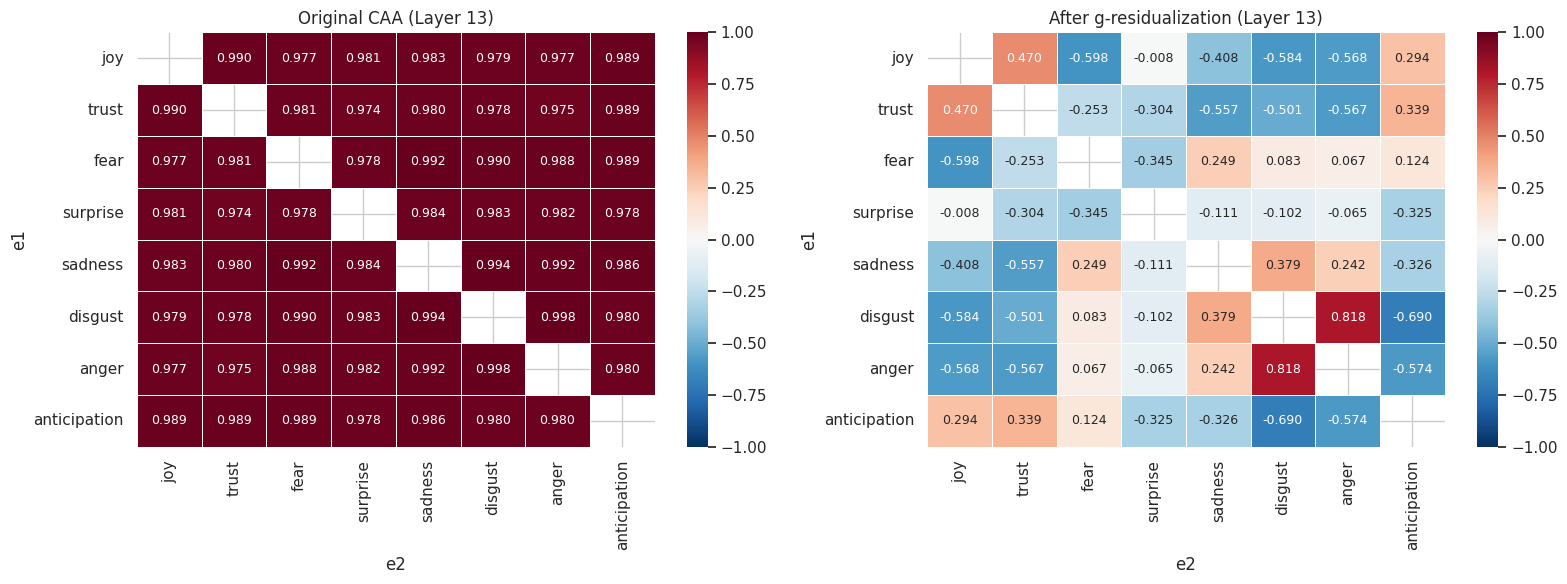

In [5]:
# Cosine heatmaps at primary layer
sub = df_heatmap[df_heatmap.layer == PRIMARY_LAYER]
mat_orig  = sub.pivot(index='e1', columns='e2', values='cos_orig').reindex(
    index=EMOTION_ORDER, columns=EMOTION_ORDER)
mat_resid = sub.pivot(index='e1', columns='e2', values='cos_resid').reindex(
    index=EMOTION_ORDER, columns=EMOTION_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
mask = np.eye(N_EMO, dtype=bool)

for ax, mat, title in [
    (axes[0], mat_orig,  f'Original CAA (Layer {PRIMARY_LAYER})'),
    (axes[1], mat_resid, f'After g-residualization (Layer {PRIMARY_LAYER})'),
]:
    sns.heatmap(
        mat, annot=True, fmt='.3f', cmap='RdBu_r',
        center=0, vmin=-1, vmax=1,
        linewidths=0.5, ax=ax, mask=mask,
        annot_kws={'size': 9},
    )
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig(OUT_DIR / f'cosine_heatmap_before_after_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

## 2. SVD / Participation Ratio before and after

The participation ratio (PR) measures the effective dimensionality:
$$\text{PR} = \frac{(\sum_k \lambda_k)^2}{\sum_k \lambda_k^2}$$
where $\lambda_k = \sigma_k^2$ are eigenvalues.

PR = 1 means all variance is on a single axis. PR = 8 means variance is evenly spread across all 8 emotion directions.

If the original directions all point near $g$, we expect PR ≈ 1 originally. After residualization, PR should increase if emotion-specific axes exist.

In [6]:
rows_svd = []

for layer in LAYER_INDICES:
    V       = get_pooled(layer)
    g, Vr   = residualize(V)
    Vr_u    = unit(Vr)

    sv_orig  = svd_summary(V)
    sv_resid = svd_summary(Vr_u)

    rows_svd.append({
        'layer': layer,
        'PR_orig':    sv_orig['pr'],
        'PR_resid':   sv_resid['pr'],
        'EVR1_orig':  float(sv_orig['evr'][0]),
        'EVR1_resid': float(sv_resid['evr'][0]),
        'EVR2_orig':  float(sv_orig['evr'][1]),
        'EVR2_resid': float(sv_resid['evr'][1]),
        'EVR3_orig':  float(sv_orig['evr'][2]),
        'EVR3_resid': float(sv_resid['evr'][2]),
        # Projection magnitude onto g (how much each emotion aligns with common direction)
        'mean_g_proj_orig': float((V @ g).mean()),
        'std_g_proj_orig':  float((V @ g).std()),
    })

df_svd = pd.DataFrame(rows_svd).set_index('layer')
df_svd.to_csv(OUT_DIR / 'svd_before_after.csv')
print(df_svd[['PR_orig', 'PR_resid', 'EVR1_orig', 'EVR1_resid']].to_string(float_format='{:.4f}'.format))

       PR_orig  PR_resid  EVR1_orig  EVR1_resid
layer                                          
8          NaN       NaN        NaN         NaN
10      3.8749    3.8796     0.4084      0.4192
13      3.6588    3.6591     0.4288      0.4443
16      3.4379    3.5180     0.4480      0.4617
19      3.4206    3.6341     0.4463      0.4484
22      3.3711    3.7387     0.4481      0.4350


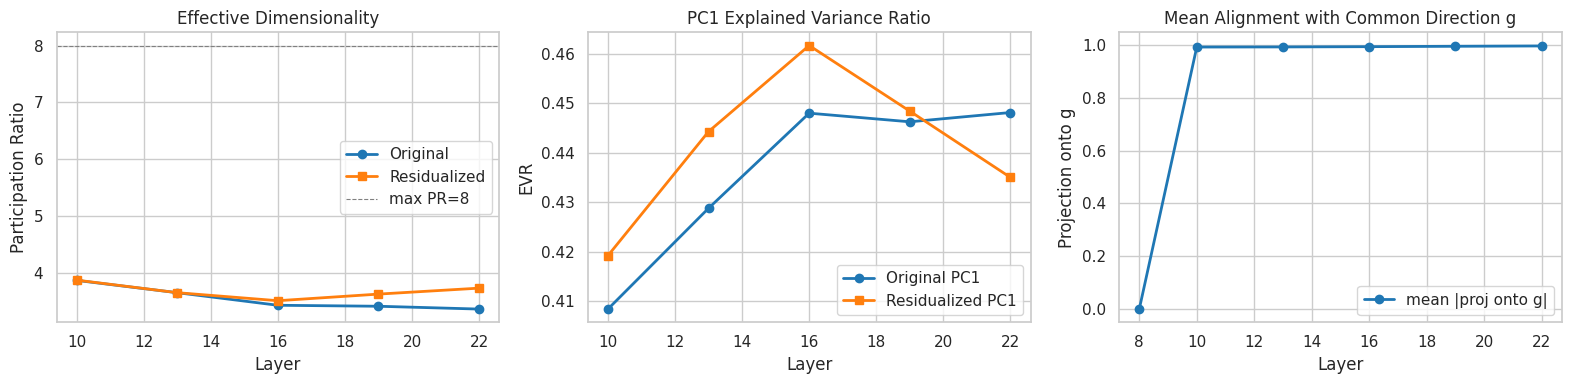

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(df_svd.index, df_svd['PR_orig'],  marker='o', label='Original', linewidth=2)
axes[0].plot(df_svd.index, df_svd['PR_resid'], marker='s', label='Residualized', linewidth=2)
axes[0].axhline(8, color='gray', linestyle='--', linewidth=0.8, label='max PR=8')
axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Participation Ratio')
axes[0].set_title('Effective Dimensionality')
axes[0].legend()

axes[1].plot(df_svd.index, df_svd['EVR1_orig'],  marker='o', label='Original PC1', linewidth=2)
axes[1].plot(df_svd.index, df_svd['EVR1_resid'], marker='s', label='Residualized PC1', linewidth=2)
axes[1].set_xlabel('Layer'); axes[1].set_ylabel('EVR')
axes[1].set_title('PC1 Explained Variance Ratio')
axes[1].legend()

axes[2].plot(df_svd.index, df_svd['mean_g_proj_orig'], marker='o', linewidth=2,
             label='mean |proj onto g|')
axes[2].fill_between(
    df_svd.index,
    df_svd['mean_g_proj_orig'] - df_svd['std_g_proj_orig'],
    df_svd['mean_g_proj_orig'] + df_svd['std_g_proj_orig'],
    alpha=0.2,
)
axes[2].set_xlabel('Layer'); axes[2].set_ylabel('Projection onto g')
axes[2].set_title('Mean Alignment with Common Direction g')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'svd_pr_before_after.png', bbox_inches='tight')
plt.show()

## 3. Plutchik pair analysis: opposite and adjacent pairs

The Plutchik wheel predicts:
- **Opposite pairs** (joy↔sadness, etc.) should be *less* similar than adjacent pairs.

Before residualization, all pairs may be similarly high. After, we test whether Plutchik structure emerges.

**Important**: We do not assume the result will match Plutchik. We simply report it.

In [8]:
rows_pairs = []

for layer in LAYER_INDICES:
    V       = get_pooled(layer)
    g, Vr   = residualize(V)

    cos_orig  = cosine_matrix(V)
    cos_resid = cosine_matrix(Vr)

    for pair_type, pairs in [('opposite', OPPOSITE_PAIRS), ('adjacent', ADJACENT_PAIRS)]:
        for a, b in pairs:
            i, j = EMO_POS[a], EMO_POS[b]
            rows_pairs.append({
                'layer': layer,
                'pair': f'{a}↔{b}',
                'type': pair_type,
                'cos_orig':  float(cos_orig[i, j]),
                'cos_resid': float(cos_resid[i, j]),
            })

df_pairs = pd.DataFrame(rows_pairs)
df_pairs.to_csv(OUT_DIR / 'plutchik_pairs_before_after.csv', index=False)

# Summary
summary = df_pairs.groupby(['type', 'layer'])[['cos_orig', 'cos_resid']].mean().round(4)
print('Mean Plutchik pair cosine by type and layer:')
print(summary.to_string())

Mean Plutchik pair cosine by type and layer:
                cos_orig  cos_resid
type     layer                     
adjacent 8        0.0000     0.0000
         10       0.9857     0.0592
         13       0.9867     0.0847
         16       0.9889     0.1039
         19       0.9916     0.1096
         22       0.9938     0.1044
opposite 8        0.0000     0.0000
         10       0.9811    -0.2630
         13       0.9817    -0.2918
         16       0.9843    -0.2917
         19       0.9882    -0.2890
         22       0.9914    -0.2676


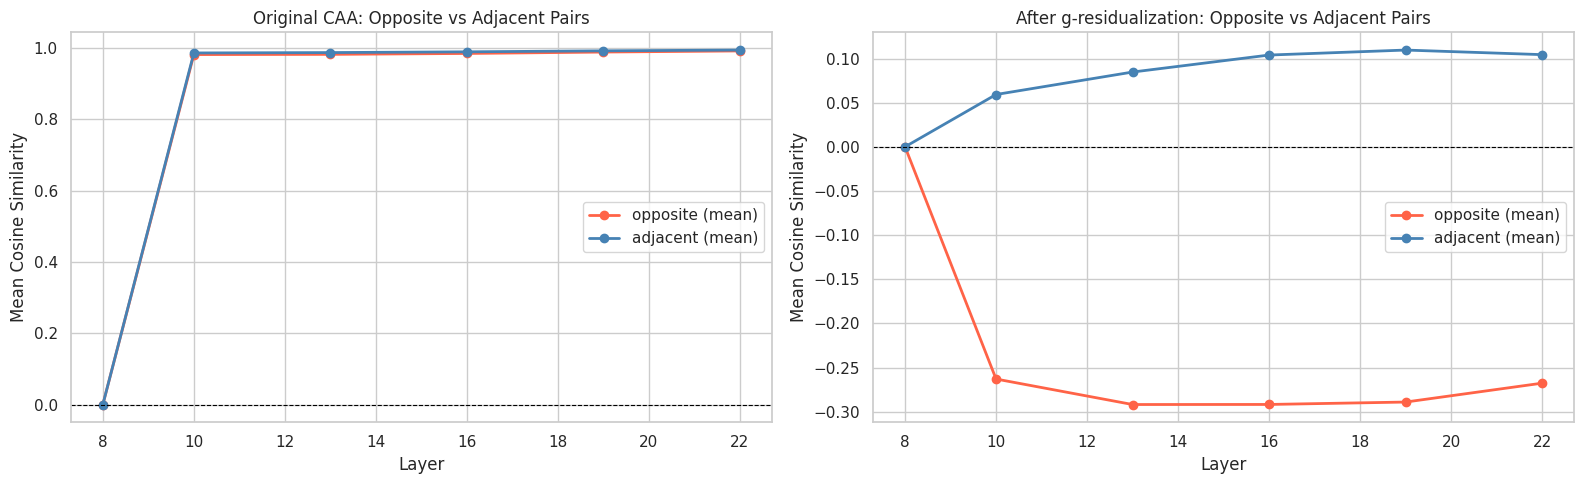

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title in [
    (axes[0], 'cos_orig',  'Original CAA'),
    (axes[1], 'cos_resid', 'After g-residualization'),
]:
    for pair_type, color in [('opposite', 'tomato'), ('adjacent', 'steelblue')]:
        sub = df_pairs[df_pairs['type'] == pair_type]
        mean_by_layer = sub.groupby('layer')[col].mean()
        ax.plot(mean_by_layer.index, mean_by_layer.values,
                marker='o', label=f'{pair_type} (mean)', color=color, linewidth=2)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Layer'); ax.set_ylabel('Mean Cosine Similarity')
    ax.set_title(f'{title}: Opposite vs Adjacent Pairs')
    ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'plutchik_pairs_before_after.png', bbox_inches='tight')
plt.show()

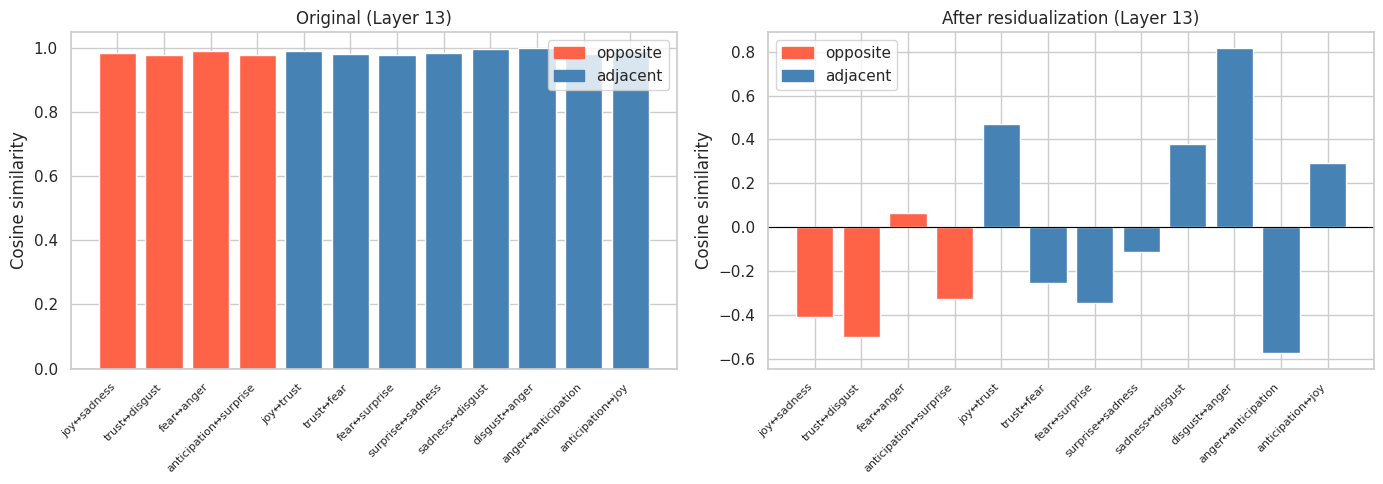

In [10]:
# Per-pair cosine before/after at primary layer
sub_primary = df_pairs[df_pairs.layer == PRIMARY_LAYER].copy()
sub_primary['delta'] = sub_primary['cos_resid'] - sub_primary['cos_orig']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sub_primary['type'].map({'opposite': 'tomato', 'adjacent': 'steelblue'})
x = np.arange(len(sub_primary))

for ax, col, title in [
    (axes[0], 'cos_orig',  'Original'),
    (axes[1], 'cos_resid', 'After residualization'),
]:
    bars = ax.bar(x, sub_primary[col], color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(sub_primary['pair'], rotation=45, ha='right', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Cosine similarity')
    ax.set_title(f'{title} (Layer {PRIMARY_LAYER})')
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='tomato', label='opposite'),
        Patch(color='steelblue', label='adjacent'),
    ])

plt.tight_layout()
plt.savefig(OUT_DIR / f'plutchik_pairs_per_pair_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

## 4. 2D PCA projection before and after residualization

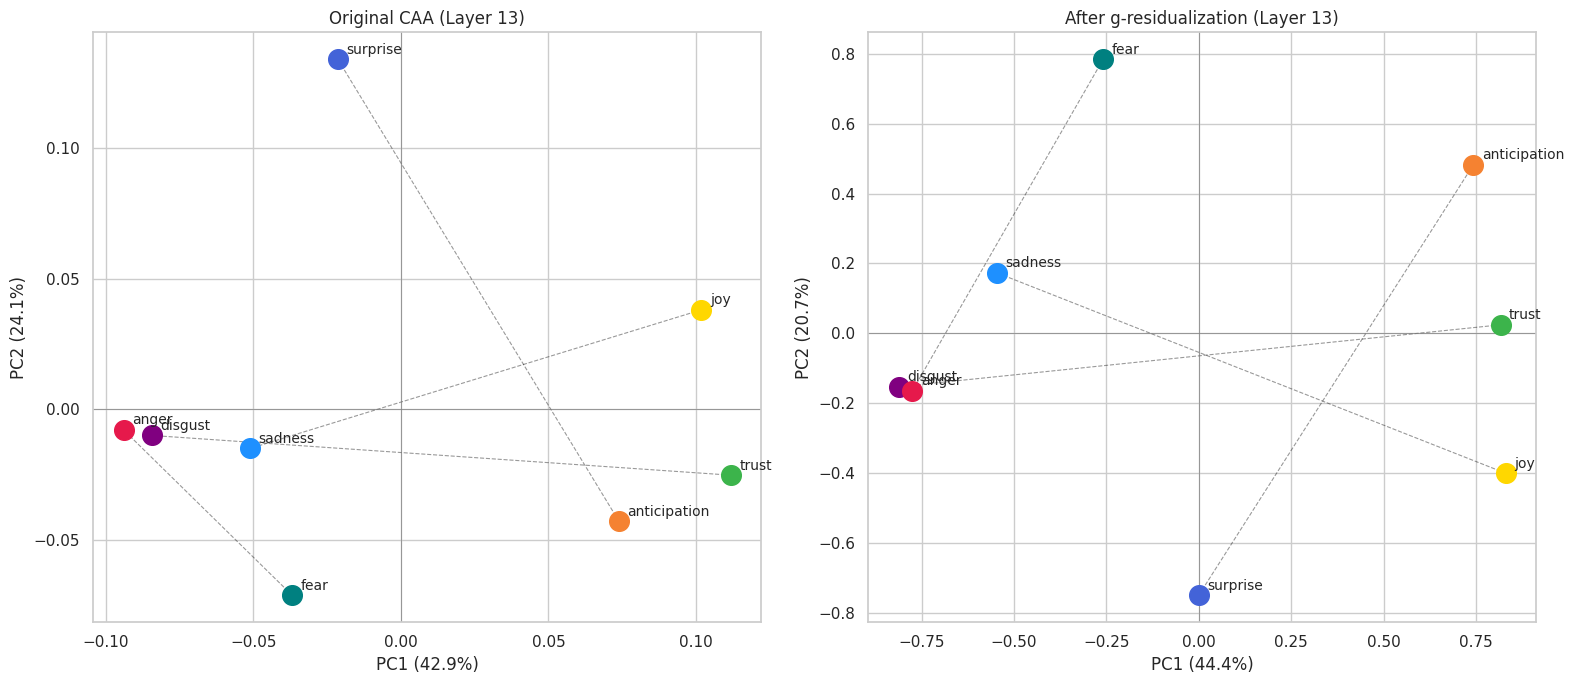

In [11]:
V       = get_pooled(PRIMARY_LAYER)
g, Vr   = residualize(V)
Vr_u    = unit(Vr)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, vecs, title in [
    (axes[0], V,    f'Original CAA (Layer {PRIMARY_LAYER})'),
    (axes[1], Vr_u, f'After g-residualization (Layer {PRIMARY_LAYER})'),
]:
    pca = PCA(n_components=2)
    proj = pca.fit_transform(vecs)  # (8, 2)
    evr  = pca.explained_variance_ratio_

    for i, emo in enumerate(EMOTION_ORDER):
        c = EMO_COLORS.get(emo, 'gray')
        ax.scatter(proj[i, 0], proj[i, 1], s=200, color=c, zorder=3)
        ax.annotate(emo, (proj[i, 0], proj[i, 1]),
                    textcoords='offset points', xytext=(6, 4), fontsize=10)

    # Draw Plutchik opposite pairs
    for a, b in OPPOSITE_PAIRS:
        i, j = EMO_POS[a], EMO_POS[b]
        ax.plot([proj[i, 0], proj[j, 0]], [proj[i, 1], proj[j, 1]],
                'k--', linewidth=0.8, alpha=0.4)

    ax.set_xlabel(f'PC1 ({evr[0]:.1%})')
    ax.set_ylabel(f'PC2 ({evr[1]:.1%})')
    ax.set_title(title, fontsize=12)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / f'pca_2d_before_after_L{PRIMARY_LAYER}.png', bbox_inches='tight')
plt.show()

## 5. Layer-wise cosine diversity summary

A compact summary showing how inter-emotion cosine diversity changes across layers, before and after residualization.

In [12]:
rows_summary = []

for layer in LAYER_INDICES:
    V       = get_pooled(layer)
    g, Vr   = residualize(V)

    cos_orig  = cosine_matrix(V)
    cos_resid = cosine_matrix(Vr)

    # Off-diagonal entries
    mask_offdiag = ~np.eye(N_EMO, dtype=bool)
    c_orig  = cos_orig[mask_offdiag]
    c_resid = cos_resid[mask_offdiag]

    # Proj of each emotion onto g
    projs = V @ g

    rows_summary.append({
        'layer': layer,
        'mean_cos_orig':    float(c_orig.mean()),
        'std_cos_orig':     float(c_orig.std()),
        'mean_cos_resid':   float(c_resid.mean()),
        'std_cos_resid':    float(c_resid.std()),
        'min_cos_resid':    float(c_resid.min()),
        'max_cos_resid':    float(c_resid.max()),
        'mean_proj_onto_g': float(projs.mean()),
        'std_proj_onto_g':  float(projs.std()),
    })

df_summary = pd.DataFrame(rows_summary).set_index('layer')
df_summary.to_csv(OUT_DIR / 'cosine_diversity_summary.csv')
print('Cosine diversity summary by layer:')
print(df_summary.to_string(float_format='{:.4f}'.format))

Cosine diversity summary by layer:
       mean_cos_orig  std_cos_orig  mean_cos_resid  std_cos_resid  min_cos_resid  max_cos_resid  mean_proj_onto_g  std_proj_onto_g
layer                                                                                                                             
8             0.0000        0.0000          0.0000         0.0000         0.0000         0.0000            0.0000           0.0000
10            0.9828        0.0061         -0.1382         0.3652        -0.6850         0.8224            0.9925           0.0019
13            0.9838        0.0063         -0.1364         0.3896        -0.6898         0.8179            0.9929           0.0021
16            0.9860        0.0061         -0.1335         0.4067        -0.6954         0.7825            0.9939           0.0023
19            0.9894        0.0048         -0.1329         0.3928        -0.6948         0.7689            0.9954           0.0020
22            0.9922        0.0038         -0.13

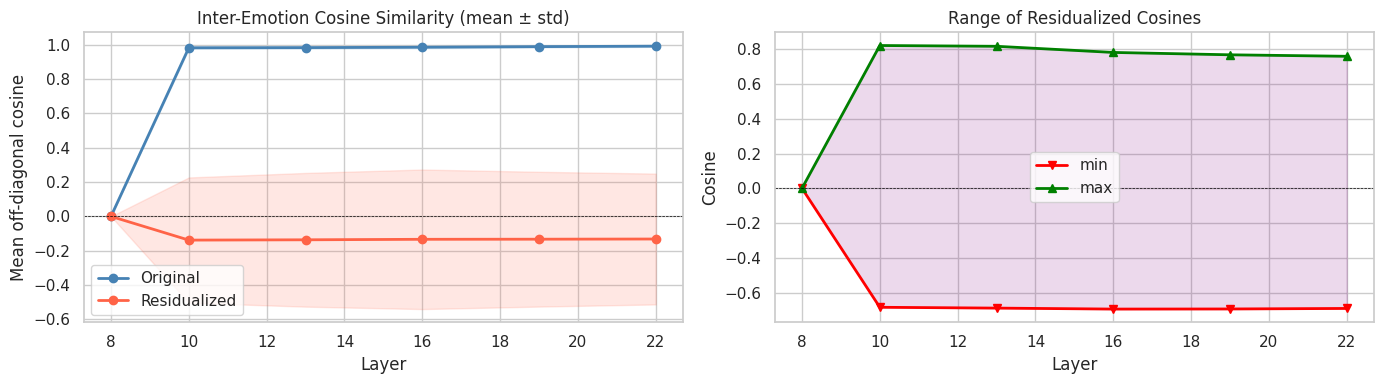

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mean and std of off-diagonal cosines
for label, mean_col, std_col, color in [
    ('Original',      'mean_cos_orig',  'std_cos_orig',  'steelblue'),
    ('Residualized',  'mean_cos_resid', 'std_cos_resid', 'tomato'),
]:
    axes[0].plot(df_summary.index, df_summary[mean_col], marker='o', label=label, color=color, linewidth=2)
    axes[0].fill_between(
        df_summary.index,
        df_summary[mean_col] - df_summary[std_col],
        df_summary[mean_col] + df_summary[std_col],
        alpha=0.15, color=color,
    )

axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Mean off-diagonal cosine')
axes[0].set_title('Inter-Emotion Cosine Similarity (mean ± std)')
axes[0].legend()

# Range after residualization
axes[1].plot(df_summary.index, df_summary['min_cos_resid'], marker='v', label='min', color='red', linewidth=2)
axes[1].plot(df_summary.index, df_summary['max_cos_resid'], marker='^', label='max', color='green', linewidth=2)
axes[1].fill_between(
    df_summary.index,
    df_summary['min_cos_resid'], df_summary['max_cos_resid'],
    alpha=0.15, color='purple',
)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_xlabel('Layer'); axes[1].set_ylabel('Cosine')
axes[1].set_title('Range of Residualized Cosines')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'cosine_diversity_by_layer.png', bbox_inches='tight')
plt.show()

## 6. All-layers heatmap comparison

Show residualized cosine heatmaps for all layers side by side.

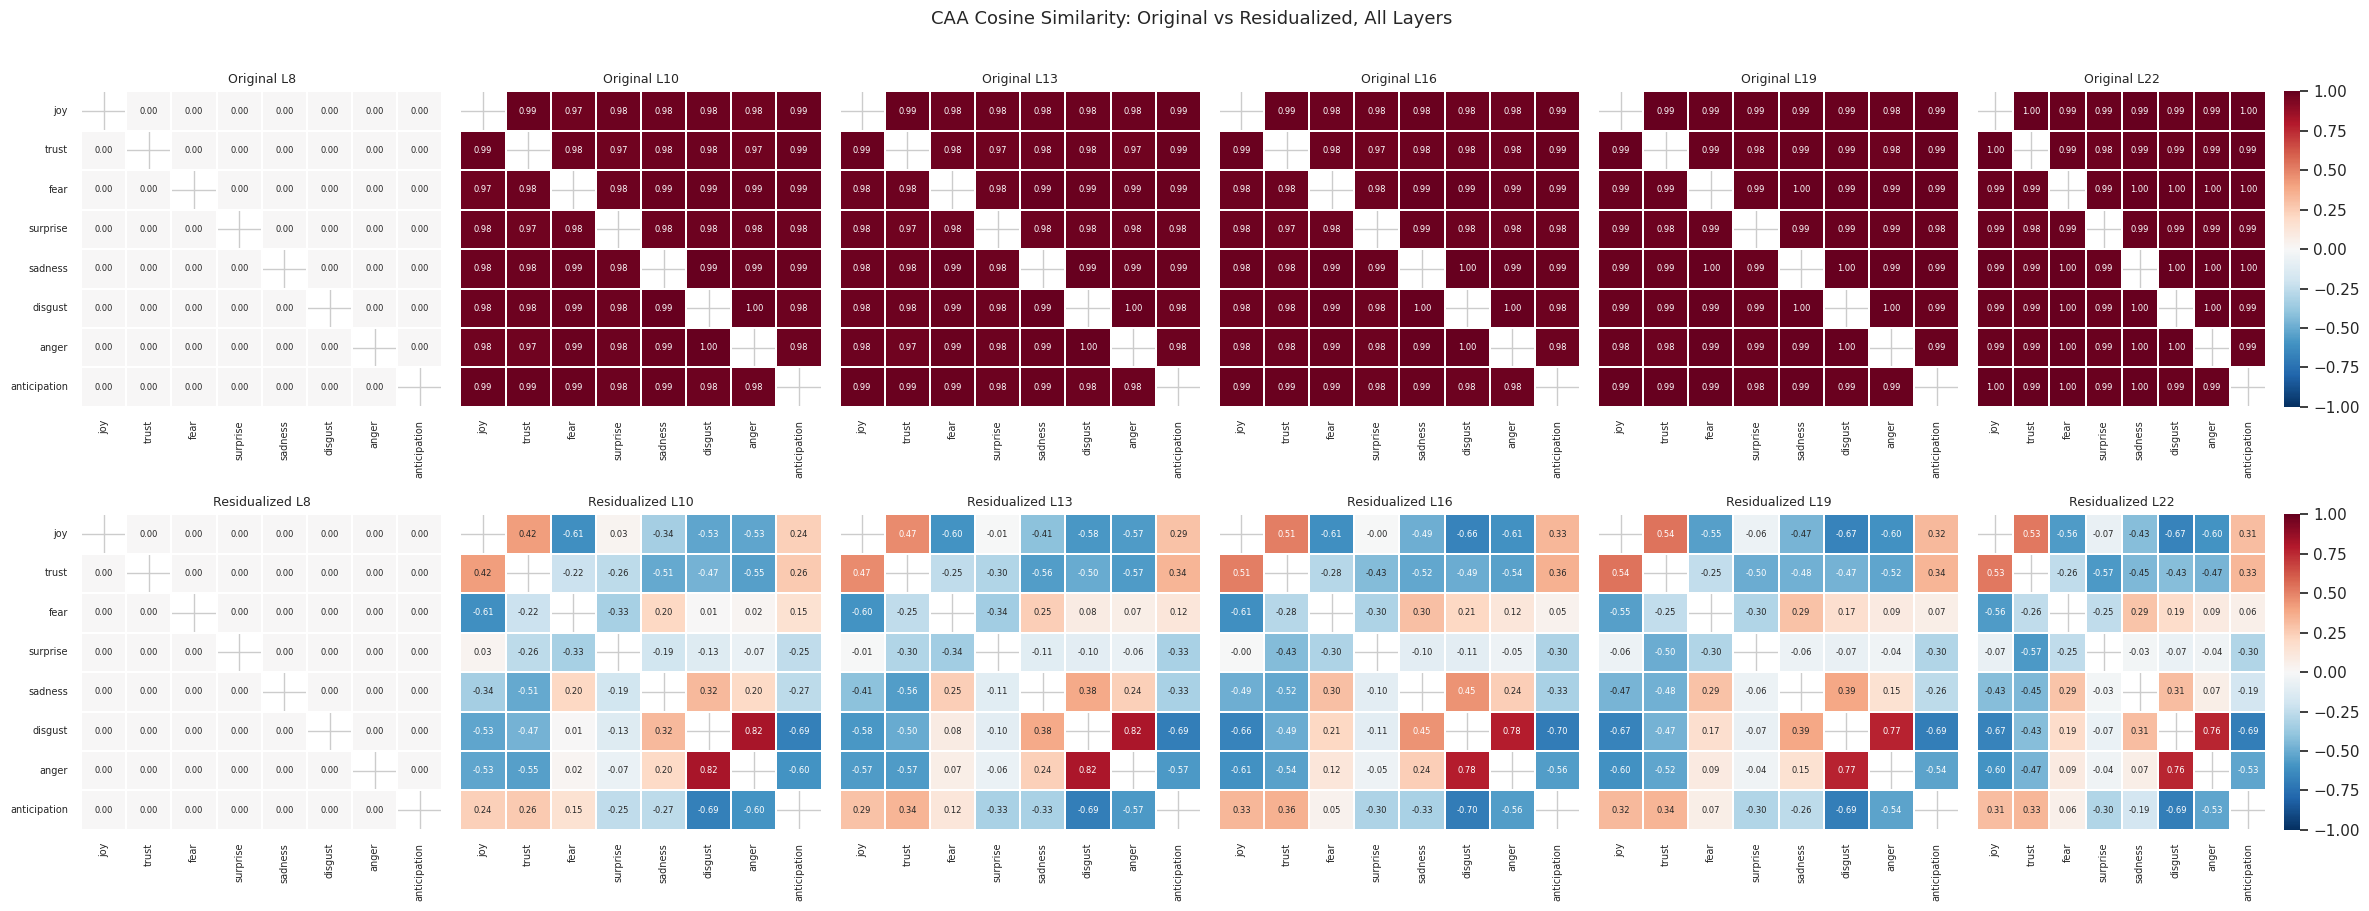

In [14]:
n_layers = len(LAYER_INDICES)
fig, axes = plt.subplots(2, n_layers, figsize=(4 * n_layers, 9))

for col_idx, layer in enumerate(LAYER_INDICES):
    V      = get_pooled(layer)
    g, Vr  = residualize(V)

    cos_orig  = cosine_matrix(V)
    cos_resid = cosine_matrix(Vr)

    mask = np.eye(N_EMO, dtype=bool)

    for row_idx, (mat, label) in enumerate([
        (cos_orig,  'Original'),
        (cos_resid, 'Residualized'),
    ]):
        ax = axes[row_idx, col_idx]
        sns.heatmap(
            pd.DataFrame(mat, index=EMOTION_ORDER, columns=EMOTION_ORDER),
            annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax, mask=mask,
            annot_kws={'size': 6},
            cbar=(col_idx == n_layers - 1),
        )
        ax.set_title(f'{label} L{layer}', fontsize=9)
        if col_idx > 0:
            ax.set_ylabel('')
            ax.set_yticklabels([])
        ax.tick_params(axis='both', labelsize=7)

plt.suptitle('CAA Cosine Similarity: Original vs Residualized, All Layers', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'cosine_heatmap_all_layers.png', bbox_inches='tight')
plt.show()

## Summary

Key outputs saved to `analysis/caa/common_direction_residualization/`:
- `cosine_before_after_by_layer.csv` — full pairwise cosine matrix before/after per layer
- `cosine_diversity_summary.csv` — layer-wise statistics
- `svd_before_after.csv` — participation ratio and EVR before/after
- `plutchik_pairs_before_after.csv` — opposite/adjacent pair cosines before/after
- PNG plots

### Interpretation guide

| Observation | Interpretation |
|---|---|
| High mean cosine (~0.9) before residualization | Strong common emotionalization direction |
| PR increases from ~1 to >2 after residualization | Emotion-specific structure exists in residual space |
| Opposite pairs (joy↔sadness) become less similar after residualization | Some Plutchik-aligned structure survives |
| Residualized vectors near zero or cosines near 0 everywhere | Emotion directions are almost identical; no specific structure |
| 2D PCA shows spread of residualized vectors | Recoverable emotion geometry exists |